# Algorithme de Grover Biaisé — Distribution Initiale Non Uniforme

Ce notebook implémente une variante de l'algorithme de Grover où l'état initial **n'est pas une superposition uniforme**.

### Idée clé
L'algorithme de Grover classique part d'une superposition uniforme $|s\rangle = H^{\otimes n}|0\rangle$, où chaque état a la même amplitude $\frac{1}{\sqrt{2^n}}$.  
Ici, on prépare un état initial **biaisé** $|\psi_0\rangle$ avec des amplitudes non égales, ce qui permet de :
- Donner plus de poids à certains états *a priori* plus probables
- Réduire le nombre d'itérations si la distribution *a priori* est bien choisie
- Modéliser des situations réelles avec information partielle

### Diffuseur généralisé
Le diffuseur de Grover classique effectue la réflexion par rapport à $|s\rangle$.  
Dans notre cas biaisé, on réfléchit par rapport à l'état initial $|\psi_0\rangle$ :
$$U_{\psi_0} = 2|\psi_0\rangle\langle\psi_0| - I$$

Ceci est implémenté par : $A \cdot (2|0\rangle\langle 0| - I) \cdot A^\dagger$ où $A$ est le circuit qui prépare $|\psi_0\rangle$.


## Imports

In [20]:
import math
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.circuit.library import MCMTGate, ZGate, StatePreparation
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

## Paramètres, distributions initiales et état cible

In [21]:
# Nombre de qubits et état cible
num_qubits = 3
N = 2 ** num_qubits  # = 8 états
marked_states = ["011"]  # = état |3⟩ (décimal)
marked_indices = [int(s, 2) for s in marked_states]

print(f"Nombre de qubits: {num_qubits}")
print(f"Nombre d'états: {N}")
print(f"État(s) cible(s): {marked_states}")
print(f"Indices cibles: {marked_indices}")


Nombre de qubits: 3
Nombre d'états: 8
État(s) cible(s): ['011']
Indices cibles: [3]


### Distributions initiales disponibles

On définit plusieurs distributions pour tester différents scénarios :

In [22]:
# Dictionnaire des distributions disponibles
DISTRIBUTIONS = {
    "favorable": np.array([0.05, 0.05, 0.1, 0.3, 0.1, 0.05, 0.3, 0.05]),
    
    "defavorable": np.array([0.25, 0.25, 0.25, 0.01, 0.10, 0.05, 0.05, 0.04]),
    
    "tres_concentree": np.array([0.02, 0.02, 0.02, 0.01, 0.02, 0.02, 0.88, 0.01]),
}

In [23]:
# Sélectionner la distribution par défaut pour le reste du notebook
selected_distribution = "favorable"
raw_probs = DISTRIBUTIONS[selected_distribution].copy()
amplitudes = np.sqrt(raw_probs)

# Amplitude et itérations optimales pour cette distribution
amplitude_cibles = np.sqrt(sum(raw_probs[i] for i in marked_indices))
optimal_num_iterations_biased = math.floor(
    math.pi / (4 * math.asin(amplitude_cibles))
)

print(f"\n--- Distribution sélectionnée: {selected_distribution.upper()} ---")
print(f"Probabilité initiale sur l'état cible : {amplitude_cibles**2:.4f}")
print(f"Amplitude sur l'état cible : {amplitude_cibles:.4f}")
print(f"Itérations optimales (biaisé) : {optimal_num_iterations_biased}")



--- Distribution sélectionnée: FAVORABLE ---
Probabilité initiale sur l'état cible : 0.3000
Amplitude sur l'état cible : 0.5477
Itérations optimales (biaisé) : 1


## Visualisation : distributions initiales

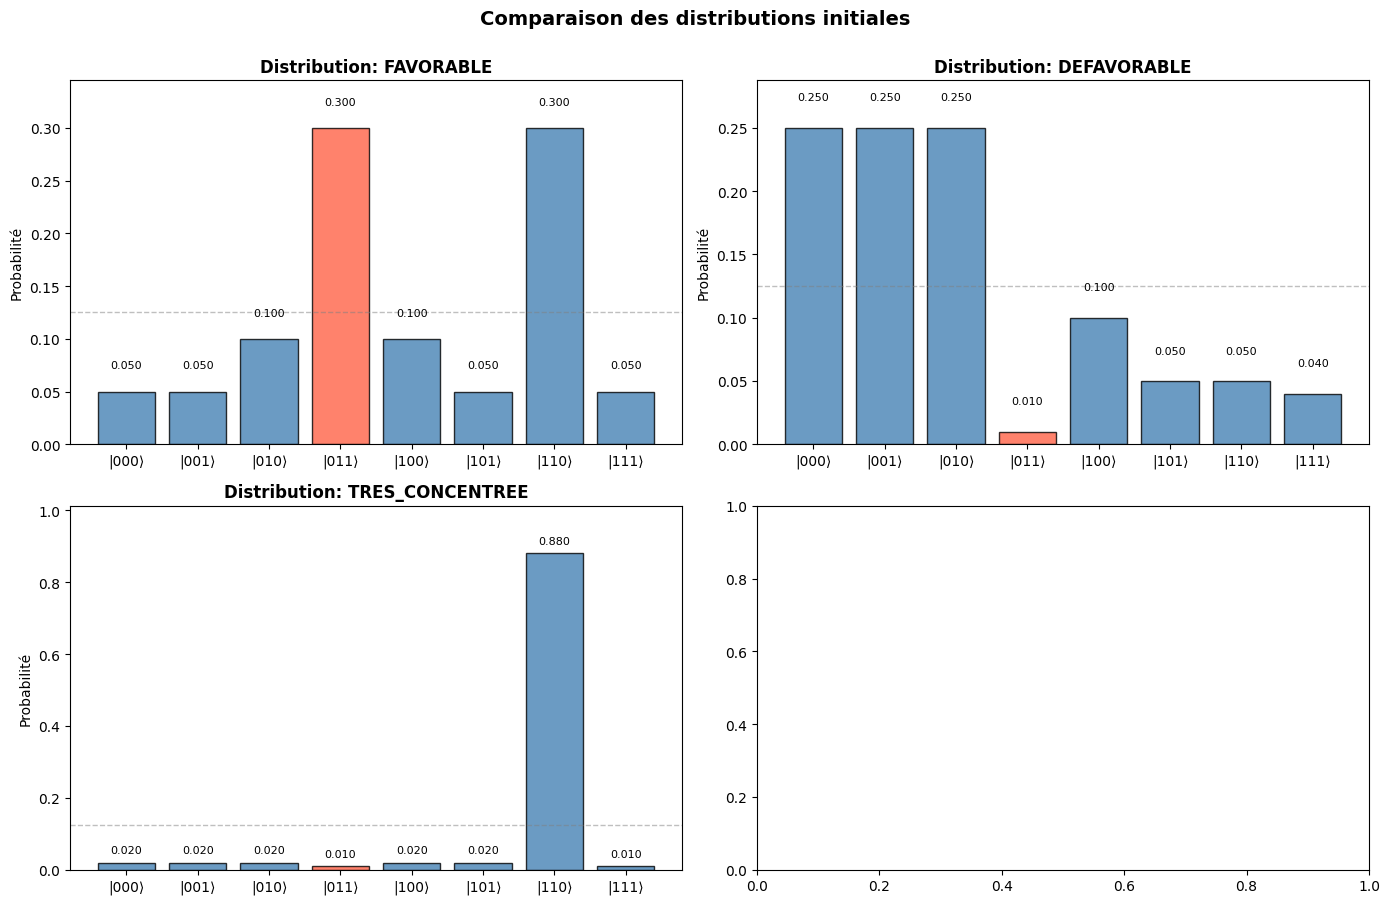

In [24]:
def plot_distribution(probs, title, ax):
    """Tracer une distribution avec coloration des états cibles."""
    labels = [f"|{i:03b}⟩" for i in range(N)]
    colors = ['tomato' if i in marked_indices else 'steelblue' for i in range(N)]
    ax.bar(labels, probs, color=colors, edgecolor='black', alpha=0.8)
    ax.axhline(1/N, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Probabilité')
    for i, val in enumerate(probs):
        ax.text(i, val + 0.02, f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_ylim(0, max(probs) * 1.15)

# Visualiser toutes les distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
for idx, (name, dist) in enumerate(DISTRIBUTIONS.items()):
    plot_distribution(dist, f"Distribution: {name.upper()}", axes[idx])
plt.suptitle('Comparaison des distributions initiales', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 3. Circuit de préparation de l'état initial $A$

On utilise `initialize` de Qiskit pour préparer directement le vecteur d'état $|\psi_0\rangle$.

Ce circuit $A$ est tel que : $A|0\rangle = |\psi_0\rangle = \sum_i \alpha_i |i\rangle$

> **Diffuseur généralisé :** Le diffuseur est construit comme $A \cdot (2|0\rangle\langle 0| - I) \cdot A^\dagger$,  
> ce qui correspond exactement à réfléchir par rapport à $|\psi_0\rangle$.

In [25]:
def build_state_prep_circuit(amplitudes):
    """Construit le circuit A qui prépare l'état |ψ₀⟩ à partir de |0⟩."""
    n = int(np.log2(len(amplitudes)))
    qc = QuantumCircuit(n, name='A')
    qc.append(StatePreparation(amplitudes), range(n))
    return qc

def grover_oracle(marked_states):
    """
    Construit l'oracle de Grover pour un ou plusieurs états marqués.
    L'oracle applique un déphasage de -1 aux états cibles.
    """
    if not isinstance(marked_states, list):
        marked_states = [marked_states]
    
    num_qubits = len(marked_states[0])
    qc = QuantumCircuit(num_qubits, name='Oracle')
    
    for target in marked_states:
        rev_target = target[::-1]  # Inversion bit-ordering Qiskit
        zero_inds = [i for i in range(num_qubits) if rev_target[i] == '0']
        qc.x(zero_inds)
        qc.compose(MCMTGate(ZGate(), num_qubits - 1, 1), inplace=True)
        qc.x(zero_inds)
    
    return qc

def build_biased_diffuser(A):
    """
    Construit le diffuseur généralisé U_ψ₀ = A · (2|0><0| - I) · A†
    """
    n = A.num_qubits
    qc = QuantumCircuit(n, name='Diffuseur')
    qc.compose(A.inverse(), inplace=True)
    
    qc.x(range(n))
    qc.compose(MCMTGate(ZGate(), n - 1, 1), inplace=True)
    qc.x(range(n))
    
    qc.compose(A, inplace=True)
    return qc

def build_degga_hybrid_diffuser(A, phi=np.pi):
    """
    Diffuseur hybride DEGGA avec paramètre de phase:
    D_{ψ0,φ} = A† · (2|0><0| - I) · A avec phase φ
    """
    n = A.num_qubits
    qc = QuantumCircuit(n, name=f'DEGGA φ={phi:.2f}')
    
    qc.compose(A.inverse(), inplace=True)
    qc.x(range(n))
    qc.compose(MCMTGate(ZGate(), n - 1, 1), inplace=True)
    qc.x(range(n))
    qc.global_phase = phi
    qc.compose(A, inplace=True)
    
    return qc

print("✓ Outils réutilisables chargés")

✓ Outils réutilisables chargés


# PARTIE A: GROVER BIAISÉ CLASSIQUE

## A.1 - Oracle de Grover (même pour les deux versions)

In [26]:
# Construction de l'oracle pour les états cibles
oracle = grover_oracle(marked_states)
print(f"Oracle pour états cibles: {marked_states}")


Oracle pour états cibles: ['011']


## A.2 - Diffuseur généralisé (réflexion par rapport à |ψ₀⟩)

Dans le Grover classique biaisé, on reflète par rapport à |ψ₀⟩ au lieu de |s⟩.
Construction: U_{ψ₀} = A · (2|0⟩⟨0| - I) · A†

In [27]:
# Préparation de l'état initial et du diffuseur pour Grover biaisé classique
A = build_state_prep_circuit(amplitudes)
diffuser_biased = build_biased_diffuser(A)

print("✓ Circuits préparés pour Grover biaisé classique")
print(f"  - État initial préparé: |ψ₀⟩ pour distribution {selected_distribution}")
print(f"  - Diffuseur: réflexion par rapport à |ψ₀⟩")
print(f"  - Itérations optimales (biaisé) : {optimal_num_iterations_biased}")


✓ Circuits préparés pour Grover biaisé classique
  - État initial préparé: |ψ₀⟩ pour distribution favorable
  - Diffuseur: réflexion par rapport à |ψ₀⟩
  - Itérations optimales (biaisé) : 1


In [28]:
def run_grover_simulation(A, oracle, diffuser, num_iterations, marked_states, shots=10000, backend=None):
    """
    Simule l'algorithme de Grover avec les composants fournis.
    
    Paramètres:
        A: Circuit de préparation de l'état initial
        oracle: Oracle de Grover
        diffuser: Circuit du diffuseur
        num_iterations: Nombre d'itérations
        marked_states: Liste des états cibles
        shots: Nombre de mesures
        backend: Simulateur (par défaut AerSimulator)
    
    Retourne:
        Tuple (counts, prob_target)
    """
    if backend is None:
        backend = AerSimulator()
    
    qc = QuantumCircuit(A.num_qubits)
    qc.compose(A, inplace=True)
    
    for _ in range(num_iterations):
        qc.compose(oracle, inplace=True)
        qc.compose(diffuser, inplace=True)
    
    qc.measure_all()
    qc_decomposed = qc.decompose().decompose().decompose().decompose()
    
    job = backend.run(qc_decomposed, shots=shots)
    result = job.result()
    counts = result.get_counts()
    
    # Probabilité de mesurer un état cible
    prob_target = sum(
        counts.get(state[::-1], 0) for state in marked_states
    ) / shots
    
    return counts, prob_target


def run_degga_hybrid(k, phi=np.pi/2, shots=10000, backend=None):
    """Simule le DEGGA hybride avec le diffuseur adapté."""
    if backend is None:
        backend = AerSimulator()
    degga_diffuser = build_degga_hybrid_diffuser(A, phi=phi)
    _, prob_target = run_grover_simulation(
        A, oracle, degga_diffuser, k, marked_states, shots=shots, backend=backend
    )
    return prob_target

print("✓ Fonction de simulation chargée")


✓ Fonction de simulation chargée


### A.3.2 - Tests du Grover biaisé classique pour différentes itérations

In [29]:
# Tester le Grover biaisé classique pour différents nombres d'itérations
max_iter_test = max(optimal_num_iterations_biased * 2, 8)
results_biased = {"k": [], "prob": []}

print(f"\n{'k':>3} {'P(cible)':>10} {'État observé':>15}")
print("-" * 35)

for k in range(0, max_iter_test + 1):
    counts, prob_target = run_grover_simulation(
        A, oracle, diffuser_biased, k, marked_states, shots=5000
    )
    results_biased["k"].append(k)
    results_biased["prob"].append(prob_target)
    
    # Meilleur résultat
    best_state = max(counts, key=counts.get) if counts else "N/A"
    print(f"{k:3d} {prob_target:10.4f} {best_state:>15}")

best_k_biased = np.argmax(results_biased["prob"])
print(f"\nMeilleur k: {best_k_biased} avec P(cible) = {results_biased['prob'][best_k_biased]:.4f}")



  k   P(cible)    État observé
-----------------------------------
  0     0.2924             011
  1     0.0108             011
  2     0.3914             110
  3     0.1662             011
  4     0.0982             011
  5     0.4338             110
  6     0.0428             011
  7     0.2374             011
  8     0.3526             110

Meilleur k: 5 avec P(cible) = 0.4338


# PARTIE B: ALGORITHME DEGGA HYBRIDE

## B.1 - Tests du DEGGA pour différents paramètres

In [30]:
# Test du DEGGA hybride: tester k et phi
k_values = np.arange(0, max_iter_test + 1)
phi_values = np.linspace(0, 2*np.pi, 9)  # 9 valeurs de phi de 0 à 2π

results_degga = {}

print(f"\nTest DEGGA hybride: balayage phi vs k")
print(f"{'k':>3}", end="")
for i, phi in enumerate(phi_values):
    print(f" {phi/np.pi:>5.1f}π", end="")
print()
print("-" * (6 + 8*len(phi_values)))

for k in k_values:
    print(f"{k:3d}", end="")
    for phi in phi_values:
        degga_diffuser = build_degga_hybrid_diffuser(A, phi=phi)
        _, prob = run_grover_simulation(
            A, oracle, degga_diffuser, k, marked_states, shots=3000
        )
        results_degga[(k, phi)] = prob
        print(f" {prob:7.4f}", end="")
    print()

# Trouver le meilleur couple (k, phi)
best_k_degga, best_phi_degga = max(results_degga, key=results_degga.get)
best_prob_degga = results_degga[(best_k_degga, best_phi_degga)]
print(f"\n✓ Meilleur DEGGA: k={best_k_degga}, φ={best_phi_degga/np.pi:.2f}π → P={best_prob_degga:.4f}")



Test DEGGA hybride: balayage phi vs k
  k   0.0π   0.2π   0.5π   0.8π   1.0π   1.2π   1.5π   1.8π   2.0π
------------------------------------------------------------------------------
  0  0.3070  0.2910  0.3160  0.2927  0.3000  0.3013  0.2913  0.3100  0.3083
  1  0.0140  0.0130  0.0107  0.0130  0.0117  0.0113  0.0080  0.0133  0.0127
  2  0.3983  0.4113  0.4150  0.4060  0.4013  0.3980  0.4137  0.3880  0.3950
  3  0.1513  0.1560  0.1580  0.1583  0.1543  0.1567  0.1643  0.1513  0.1450
  4  0.1050  0.1087  0.0973  0.1103  0.0997  0.1087  0.0993  0.1000  0.0940
  5  0.4180  0.4337  0.4223  0.4207  0.4317  0.4260  0.4240  0.4213  0.4340
  6  0.0470  0.0407  0.0380  0.0410  0.0463  0.0400  0.0447  0.0433  0.0417
  7  0.2383  0.2417  0.2243  0.2433  0.2407  0.2437  0.2447  0.2460  0.2347
  8  0.3440  0.3587  0.3380  0.3643  0.3340  0.3607  0.3630  0.3633  0.3563

✓ Meilleur DEGGA: k=5, φ=2.00π → P=0.4340


## B.2 - Visualisation des performances du DEGGA

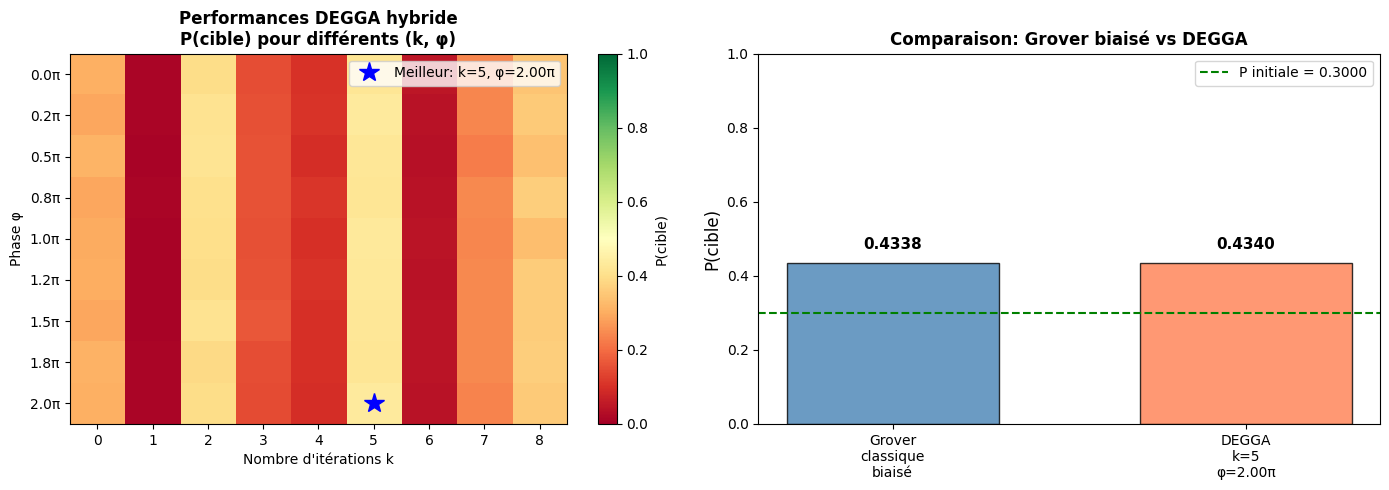

In [31]:
# Créer une matrice pour visualiser les performances du DEGGA
matrix_degga = np.zeros((len(phi_values), len(k_values)))
for i, phi in enumerate(phi_values):
    for j, k in enumerate(k_values):
        matrix_degga[i, j] = results_degga.get((k, phi), 0)

# Visualisation heatmap
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap DEGGA
im = ax1.imshow(matrix_degga, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax1.set_xticks(range(len(k_values)))
ax1.set_xticklabels(k_values)
ax1.set_yticks(range(len(phi_values)))
ax1.set_yticklabels([f"{p/np.pi:.1f}π" for p in phi_values])
ax1.set_xlabel('Nombre d\'itérations k')
ax1.set_ylabel('Phase φ')
ax1.set_title('Performances DEGGA hybride\nP(cible) pour différents (k, φ)', fontweight='bold')
plt.colorbar(im, ax=ax1, label='P(cible)')

# Marquer le meilleur
best_j = int(np.argwhere(k_values == best_k_degga)[0][0])
best_i = int(np.argwhere(phi_values == best_phi_degga)[0][0])
ax1.plot(best_j, best_i, 'b*', markersize=15, label=f'Meilleur: k={best_k_degga}, φ={best_phi_degga/np.pi:.2f}π')
ax1.legend()

# Comparaison: Grover classique vs DEGGA optimal
methods = ['Grover\nclassique\nbiaisé', f'DEGGA\nk={best_k_degga}\nφ={best_phi_degga/np.pi:.2f}π']
probs = [results_biased["prob"][best_k_biased], best_prob_degga]
colors = ['steelblue', 'coral']
bars = ax2.bar(methods, probs, color=colors, edgecolor='black', alpha=0.8, width=0.6)
ax2.axhline(amplitude_cibles**2, color='green', linestyle='--', label=f'P initiale = {amplitude_cibles**2:.4f}')
ax2.set_ylabel('P(cible)', fontsize=12)
ax2.set_title('Comparaison: Grover biaisé vs DEGGA', fontweight='bold')
ax2.set_ylim(0, 1.0)
ax2.legend()
for bar, prob in zip(bars, probs):
    ax2.text(bar.get_x() + bar.get_width()/2, prob + 0.03, f'{prob:.4f}', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


In [14]:
# Comparaison entre le Grover biaisé standard et le DEGGA hybride

def run_biased_grover_statevector(k, backend=None):
    if backend is None:
        backend = AerSimulator()

    qc = QuantumCircuit(A.num_qubits)
    qc.compose(A, inplace=True)
    diffuser = build_biased_diffuser(A)

    for _ in range(k):
        qc.compose(oracle, inplace=True)
        qc.compose(diffuser, inplace=True)

    qc = qc.decompose().decompose().decompose().decompose()
    qc.measure_all()
    job = backend.run(qc, shots=10000)
    result = job.result()
    counts = result.get_counts()
    target_state = marked_states[0][::-1]  # inverser l'ordre des bits
    prob = counts.get(target_state, 0) / 10000
    return prob

k_compare = optimal_num_iterations_biased
prob_standard_biased = run_biased_grover_statevector(k_compare)
_, prob_degga_hybrid = run_grover_simulation(
    A,
    oracle,
    build_degga_hybrid_diffuser(A, phi=np.pi/2),
    k_compare,
    marked_states,
    shots=10000,
    backend=AerSimulator(),
)

print(f"Nombre d'itérations pour la comparaison : k = {k_compare}")
print(f"Probabilité cible - Grover biaisé standard : {prob_standard_biased:.4f}")
print(f"Probabilité cible - DEGGA hybride (phi=pi/2) : {prob_degga_hybrid:.4f}")
if prob_standard_biased > 0:
    print(f"Gain relatif : {prob_degga_hybrid/prob_standard_biased:.3f}x")
else:
    print("Gain relatif : impossible à calculer (probabilité standard = 0)")

Nombre d'itérations pour la comparaison : k = 1
Probabilité cible - Grover biaisé standard : 0.0109
Probabilité cible - DEGGA hybride (phi=pi/2) : 0.0127
Gain relatif : 1.165x


# PARTIE C: COMPARAISONS AVANCÉES

## C.1 - Comparaison systématique: Grover classique vs DEGGA sur toutes les distributions

In [15]:
# Comparaison complète sur TOUTES les distributions
comparison_results = {}

print("\n" + "="*80)
print("COMPARAISON COMPLÈTE: Grover biaisé vs DEGGA sur toutes les distributions")
print("="*80)

for dist_name, dist_probs in DISTRIBUTIONS.items():
    print(f"\n► Distribution: {dist_name.upper()}")
    print("-" * 80)
    
    # Préparer les circuits pour cette distribution
    amp = np.sqrt(dist_probs)
    A_dist = build_state_prep_circuit(amp)
    diff_biased_dist = build_biased_diffuser(A_dist)
    
    # Amplitude sur cible
    amp_target = np.sqrt(sum(dist_probs[i] for i in marked_indices))
    
    # Meilleur k pour Grover biaisé
    best_k_dist = 0
    best_prob_biased = 0
    for k in range(0, 8):
        _, prob = run_grover_simulation(A_dist, oracle, diff_biased_dist, k, marked_states, shots=2000)
        if prob > best_prob_biased:
            best_prob_biased = prob
            best_k_dist = k
    
    # Meilleur (k, phi) pour DEGGA
    best_prob_degga_dist = 0
    best_params_dist = (0, np.pi)
    phi_test = np.linspace(0, 2*np.pi, 5)
    for k in range(0, 8):
        for phi in phi_test:
            degga_diff = build_degga_hybrid_diffuser(A_dist, phi=phi)
            _, prob = run_grover_simulation(A_dist, oracle, degga_diff, k, marked_states, shots=2000)
            if prob > best_prob_degga_dist:
                best_prob_degga_dist = prob
                best_params_dist = (k, phi)
    
    k_best_degga, phi_best_degga = best_params_dist
    
    # Comparaison initiale
    amp_init = np.sqrt(dist_probs[marked_indices[0]])
    
    # Résultats
    comparison_results[dist_name] = {
        "P_init": amp_init**2,
        "P_biased": best_prob_biased,
        "k_biased": best_k_dist,
        "P_degga": best_prob_degga_dist,
        "k_degga": k_best_degga,
        "phi_degga": phi_best_degga,
    }
    
    gain_absolute = best_prob_degga_dist - best_prob_biased
    gain_relative = best_prob_degga_dist / best_prob_biased if best_prob_biased > 0 else 0
    
    print(f"  P initiale (cible)    : {amp_init**2:.4f}")
    print(f"  Grover biaisé         : P={best_prob_biased:.4f} (k={best_k_dist})")
    print(f"  DEGGA hybride         : P={best_prob_degga_dist:.4f} (k={k_best_degga}, φ={phi_best_degga/np.pi:.2f}π)")
    print(f"  Gain absolu           : {gain_absolute:+.4f}")
    print(f"  Gain relatif          : {gain_relative:.3f}x")

print("\n" + "="*80)



COMPARAISON COMPLÈTE: Grover biaisé vs DEGGA sur toutes les distributions

► Distribution: FAVORABLE
--------------------------------------------------------------------------------
  P initiale (cible)    : 0.3000
  Grover biaisé         : P=0.4255 (k=5)
  DEGGA hybride         : P=0.4290 (k=5, φ=2.00π)
  Gain absolu           : +0.0035
  Gain relatif          : 1.008x

► Distribution: DEFAVORABLE
--------------------------------------------------------------------------------
  P initiale (cible)    : 0.0100
  Grover biaisé         : P=0.0485 (k=0)
  DEGGA hybride         : P=0.0560 (k=1, φ=1.50π)
  Gain absolu           : +0.0075
  Gain relatif          : 1.155x

► Distribution: TRES_CONCENTREE
--------------------------------------------------------------------------------
  P initiale (cible)    : 0.0100
  Grover biaisé         : P=0.8795 (k=0)
  DEGGA hybride         : P=0.8915 (k=0, φ=1.50π)
  Gain absolu           : +0.0120
  Gain relatif          : 1.014x



Circuit de Grover biaisé (1 itération(s)) :


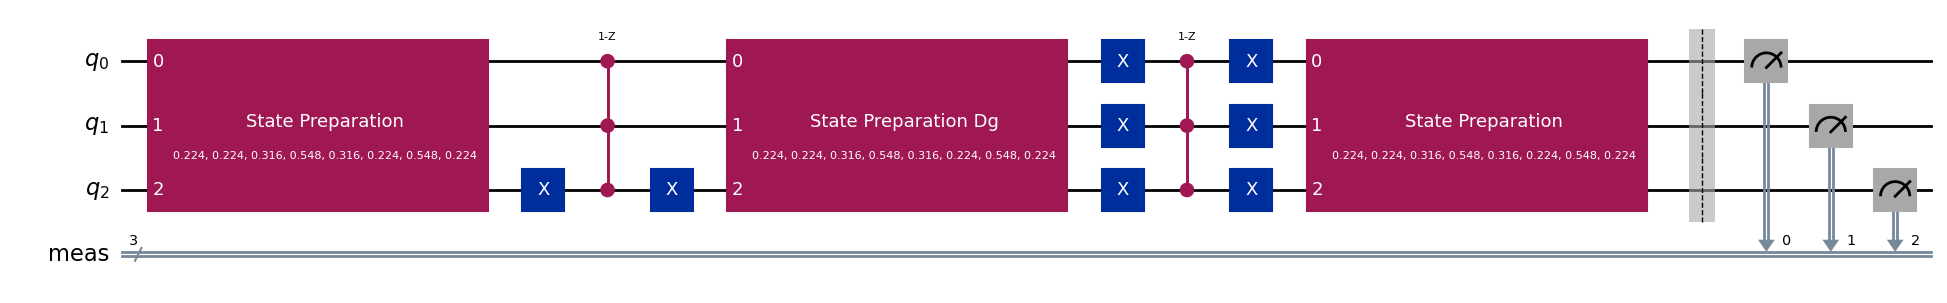

C:\Users\julie\AppData\Local\Temp\ipykernel_10660\287489719.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([d.capitalize() for d in dist_names], rotation=15)
C:\Users\julie\AppData\Local\Temp\ipykernel_10660\287489719.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([d.capitalize() for d in dist_names], rotation=15)


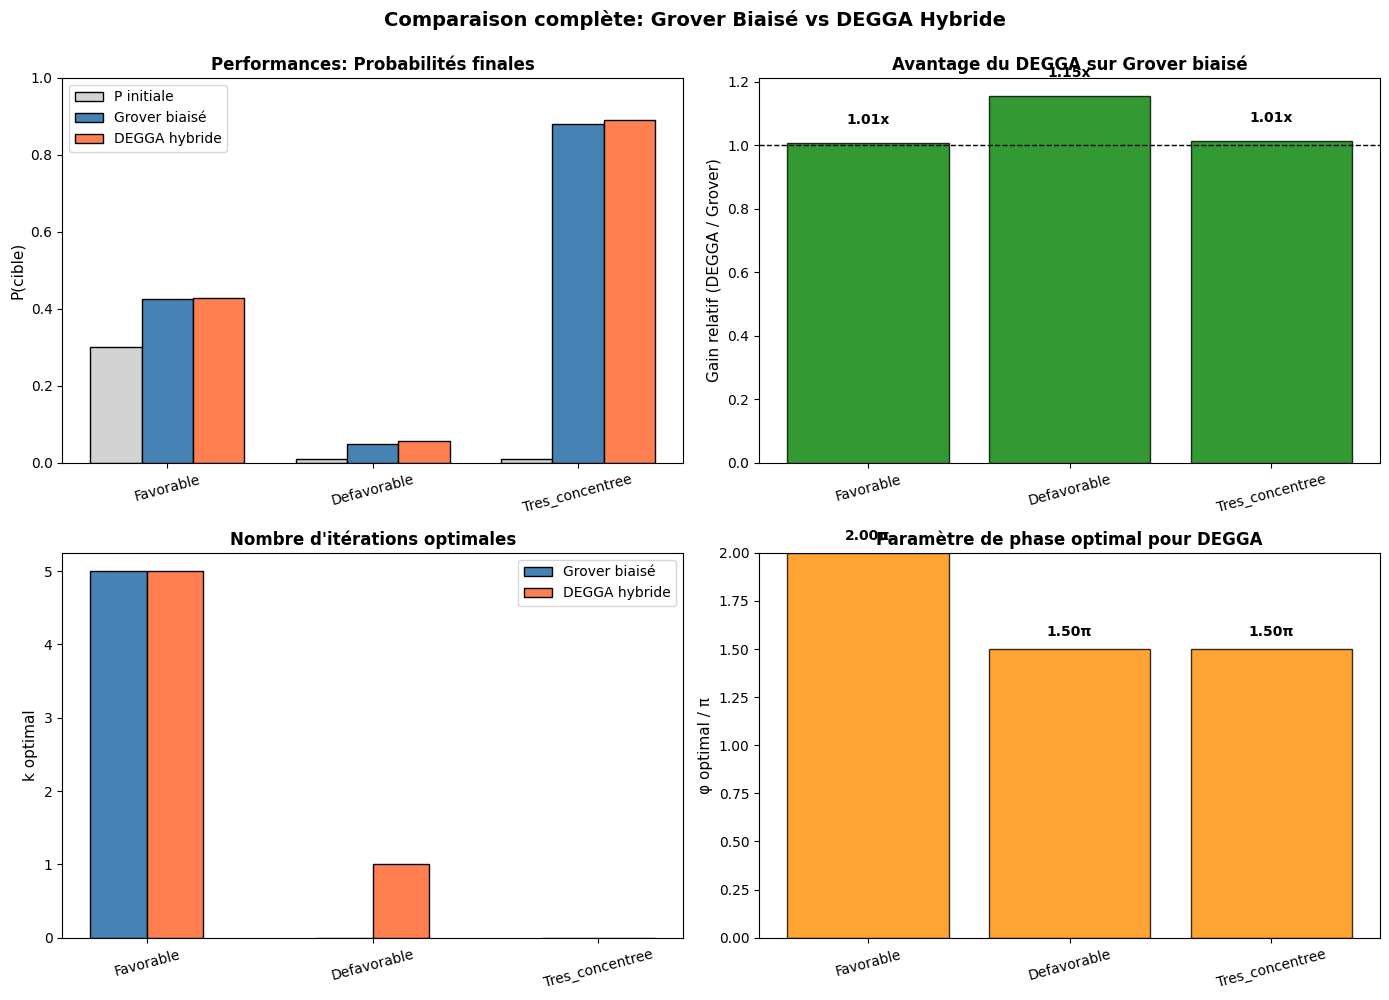

In [16]:
# Visualisation comparée des résultats sur toutes les distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

dist_names = list(comparison_results.keys())
x_pos = np.arange(len(dist_names))

# Graphique 1: Probabilités initiales vs finales
ax = axes[0]
p_init = [comparison_results[d]["P_init"] for d in dist_names]
p_biased = [comparison_results[d]["P_biased"] for d in dist_names]
p_degga = [comparison_results[d]["P_degga"] for d in dist_names]

width = 0.25
ax.bar(x_pos - width, p_init, width, label='P initiale', color='lightgray', edgecolor='black')
ax.bar(x_pos, p_biased, width, label='Grover biaisé', color='steelblue', edgecolor='black')
ax.bar(x_pos + width, p_degga, width, label='DEGGA hybride', color='coral', edgecolor='black')
ax.set_ylabel('P(cible)', fontsize=11)
ax.set_title('Performances: Probabilités finales', fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([d.capitalize() for d in dist_names], rotation=15)
ax.legend()
ax.set_ylim(0, 1.0)

# Graphique 2: Gains relatifs DEGGA/Grover
ax = axes[1]
gains = [comparison_results[d]["P_degga"] / (comparison_results[d]["P_biased"] + 1e-10) 
         for d in dist_names]
colors_gain = ['green' if g > 1 else 'red' if g < 1 else 'gray' for g in gains]
ax.bar(dist_names, gains, color=colors_gain, edgecolor='black', alpha=0.8)
ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
ax.set_ylabel('Gain relatif (DEGGA / Grover)', fontsize=11)
ax.set_title('Avantage du DEGGA sur Grover biaisé', fontweight='bold')
ax.set_xticklabels([d.capitalize() for d in dist_names], rotation=15)
for i, g in enumerate(gains):
    ax.text(i, g + 0.05, f'{g:.2f}x', ha='center', va='bottom', fontweight='bold')

# Graphique 3: Nombres d'itérations optimales
ax = axes[2]
k_biased = [comparison_results[d]["k_biased"] for d in dist_names]
k_degga = [comparison_results[d]["k_degga"] for d in dist_names]
ax.bar(x_pos - width/2, k_biased, width, label='Grover biaisé', color='steelblue', edgecolor='black')
ax.bar(x_pos + width/2, k_degga, width, label='DEGGA hybride', color='coral', edgecolor='black')
ax.set_ylabel('k optimal', fontsize=11)
ax.set_title('Nombre d\'itérations optimales', fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([d.capitalize() for d in dist_names], rotation=15)
ax.legend()

# Graphique 4: Paramètres DEGGA optimaux (φ)
ax = axes[3]
phi_degga_deg = [comparison_results[d]["phi_degga"] / np.pi for d in dist_names]
ax.bar(dist_names, phi_degga_deg, color='darkorange', edgecolor='black', alpha=0.8)
ax.set_ylabel('φ optimal / π', fontsize=11)
ax.set_title('Paramètre de phase optimal pour DEGGA', fontweight='bold')
ax.set_xticklabels([d.capitalize() for d in dist_names], rotation=15)
ax.set_ylim(0, 2.0)
for i, phi in enumerate(phi_degga_deg):
    ax.text(i, phi + 0.05, f'{phi:.2f}π', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Comparaison complète: Grover Biaisé vs DEGGA Hybride', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


## C.3 - Tableau récapitulatif des résultats

In [17]:
# Créer un tableau récapitulatif
import pandas as pd

if 'comparison_results' not in globals():
    comparison_results = {}
    print("comparison_results introuvable. Calcul des résultats de comparaison en temps réel...")
    for dist_name, dist_probs in DISTRIBUTIONS.items():
        amp = np.sqrt(dist_probs)
        A_dist = build_state_prep_circuit(amp)
        diff_biased_dist = build_biased_diffuser(A_dist)

        best_prob_biased = 0
        best_k_dist = 0
        for k in range(0, 8):
            _, prob = run_grover_simulation(A_dist, oracle, diff_biased_dist, k, marked_states, shots=2000)
            if prob > best_prob_biased:
                best_prob_biased = prob
                best_k_dist = k

        best_prob_degga_dist = 0
        best_params_dist = (0, np.pi)
        phi_test = np.linspace(0, 2 * np.pi, 5)
        for k in range(0, 8):
            for phi in phi_test:
                degga_diff = build_degga_hybrid_diffuser(A_dist, phi=phi)
                _, prob = run_grover_simulation(A_dist, oracle, degga_diff, k, marked_states, shots=2000)
                if prob > best_prob_degga_dist:
                    best_prob_degga_dist = prob
                    best_params_dist = (k, phi)

        k_best_degga, phi_best_degga = best_params_dist
        amp_init = np.sqrt(dist_probs[marked_indices[0]])

        comparison_results[dist_name] = {
            "P_init": amp_init**2,
            "P_biased": best_prob_biased,
            "k_biased": best_k_dist,
            "P_degga": best_prob_degga_dist,
            "k_degga": k_best_degga,
            "phi_degga": phi_best_degga,
        }

data = []
for dist_name, res in comparison_results.items():
    data.append({
        "Distribution": dist_name.capitalize(),
        "P initial": f"{res['P_init']:.4f}",
        "Grover (P)": f"{res['P_biased']:.4f}",
        "Grover (k)": res['k_biased'],
        "DEGGA (P)": f"{res['P_degga']:.4f}",
        "DEGGA (k)": res['k_degga'],
        "DEGGA (φ/π)": f"{res['phi_degga']/np.pi:.2f}",
        "Gain": f"{res['P_degga']/res['P_biased']:.3f}x" if res['P_biased'] > 0 else "N/A",
    })

df = pd.DataFrame(data)
print("\nRÉCAPITULATIF DES RÉSULTATS")
print("="*120)
print(df.to_string(index=False))
print("="*120)



RÉCAPITULATIF DES RÉSULTATS
   Distribution P initial Grover (P)  Grover (k) DEGGA (P)  DEGGA (k) DEGGA (φ/π)   Gain
      Favorable    0.3000     0.4255           5    0.4290          5        2.00 1.008x
    Defavorable    0.0100     0.0485           0    0.0560          1        1.50 1.155x
Tres_concentree    0.0100     0.8795           0    0.8915          0        1.50 1.014x


## C.4 - Analyse détaillée pour une distribution spécifique

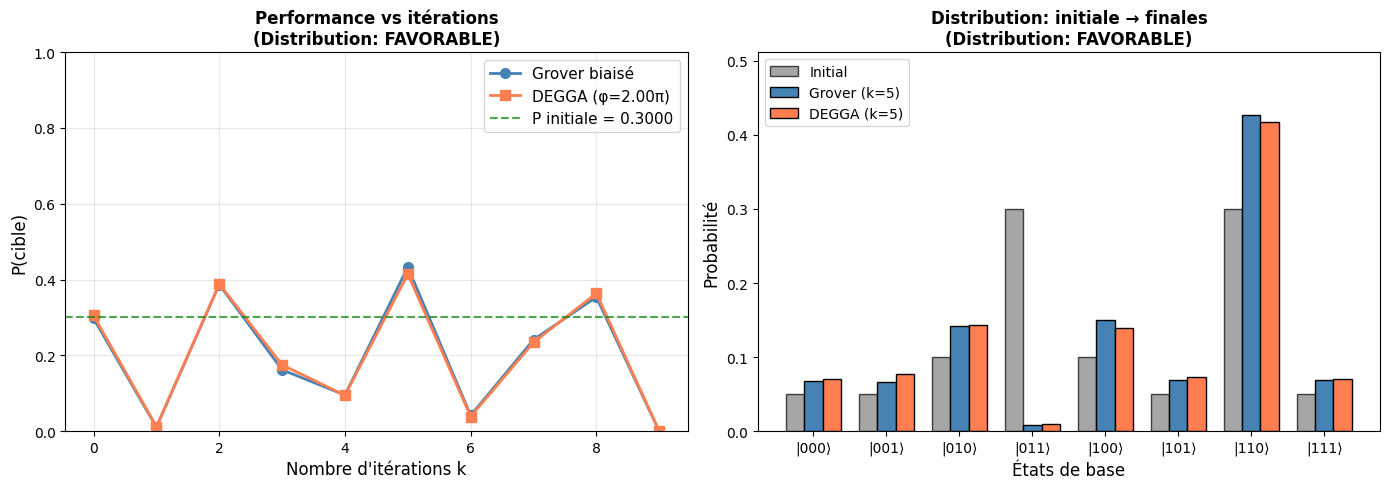

Analyse distribution 'FAVORABLE':
  Grover: k_opt=5, P=0.4330
  DEGGA:  k_opt=5, P=0.4147


In [18]:
# Sélectionner une distribution pour analyse détaillée
analysis_dist = "favorable"  # Changer ici pour analyser une autre distribution
dist_probs_analysis = DISTRIBUTIONS[analysis_dist].copy()

# Refaire les simulations pour cette distribution
amp_analysis = np.sqrt(dist_probs_analysis)
A_analysis = build_state_prep_circuit(amp_analysis)
diff_analysis = build_biased_diffuser(A_analysis)

k_values_analysis = range(0, 10)
probs_biased_analysis = []
probs_degga_analysis = []

# Récupérer une phase φ pré-calculée si elle existe, sinon déterminer la meilleure
best_phi = None
comparison_results = globals().get("comparison_results", None)
if comparison_results is not None and analysis_dist in comparison_results:
    best_phi = comparison_results[analysis_dist].get("phi_degga")

if best_phi is None:
    print(f"comparison_results introuvable ou '{analysis_dist}' absent; calcul de φ optimal.")
    phi_test = np.linspace(0, 2 * np.pi, 9)
    best_phi = np.pi
    best_prob = -1.0
    for k in k_values_analysis:
        for phi in phi_test:
            degga_diff = build_degga_hybrid_diffuser(A_analysis, phi=phi)
            _, prob = run_grover_simulation(A_analysis, oracle, degga_diff, k, marked_states, shots=2000)
            if prob > best_prob:
                best_prob = prob
                best_phi = phi

for k in k_values_analysis:
    # Grover biaisé
    _, p_b = run_grover_simulation(A_analysis, oracle, diff_analysis, k, marked_states, shots=3000)
    probs_biased_analysis.append(p_b)
    
    # DEGGA avec la phase optimale
    diff_degga_analysis = build_degga_hybrid_diffuser(A_analysis, phi=best_phi)
    _, p_d = run_grover_simulation(A_analysis, oracle, diff_degga_analysis, k, marked_states, shots=3000)
    probs_degga_analysis.append(p_d)

# Visualiser
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Courbes de probabilité vs k
ax1.plot(k_values_analysis, probs_biased_analysis, 'o-', linewidth=2, 
         markersize=7, label='Grover biaisé', color='steelblue')
ax1.plot(k_values_analysis, probs_degga_analysis, 's-', linewidth=2, 
         markersize=7, label=f'DEGGA (φ={best_phi/np.pi:.2f}π)', 
         color='coral')
amp_init = np.sqrt(dist_probs_analysis[marked_indices[0]])
ax1.axhline(amp_init**2, color='green', linestyle='--', alpha=0.7, 
           label=f'P initiale = {amp_init**2:.4f}')
ax1.set_xlabel('Nombre d\'itérations k', fontsize=12)
ax1.set_ylabel('P(cible)', fontsize=12)
ax1.set_title(f'Performance vs itérations\n(Distribution: {analysis_dist.upper()})', fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1.0)

# Résultats finaux: distribution initiale vs après
labels_states = [f"|{i:03b}⟩" for i in range(N)]
best_k_b = np.argmax(probs_biased_analysis)
best_k_d = np.argmax(probs_degga_analysis)

# Simuler les résultats finaux
A_analysis = build_state_prep_circuit(amp_analysis)
diff_analysis = build_biased_diffuser(A_analysis)
counts_b, _ = run_grover_simulation(A_analysis, oracle, diff_analysis, best_k_b, marked_states, shots=5000)
final_probs_b = [counts_b.get(f'{i:03b}', 0) / 5000 for i in range(N)]

diff_degga_analysis = build_degga_hybrid_diffuser(A_analysis, phi=best_phi)
counts_d, _ = run_grover_simulation(A_analysis, oracle, diff_degga_analysis, best_k_d, marked_states, shots=5000)
final_probs_d = [counts_d.get(f'{i:03b}', 0) / 5000 for i in range(N)]

x = np.arange(len(labels_states))
width = 0.25
colors_states = ['tomato' if i in marked_indices else 'lightblue' for i in range(N)]

ax2.bar(x - width, dist_probs_analysis, width, label='Initial', color='gray', edgecolor='black', alpha=0.7)
ax2.bar(x, final_probs_b, width, label=f'Grover (k={best_k_b})', color='steelblue', edgecolor='black')
ax2.bar(x + width, final_probs_d, width, label=f'DEGGA (k={best_k_d})', color='coral', edgecolor='black')
ax2.set_xlabel('États de base', fontsize=12)
ax2.set_ylabel('Probabilité', fontsize=12)
ax2.set_title(f'Distribution: initiale → finales\n(Distribution: {analysis_dist.upper()})', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(labels_states)
ax2.legend(fontsize=10)
ax2.set_ylim(0, max(np.max(dist_probs_analysis), np.max(final_probs_b), np.max(final_probs_d)) * 1.2)

plt.tight_layout()
plt.show()

print(f"Analyse distribution '{analysis_dist.upper()}':")
print(f"  Grover: k_opt={best_k_b}, P={probs_biased_analysis[best_k_b]:.4f}")
print(f"  DEGGA:  k_opt={best_k_d}, P={probs_degga_analysis[best_k_d]:.4f}")



In [19]:
## C.5 - Fonction d'évaluation de la probabilité de succès après différentes itérations

def evaluate_success_probability(distribution_name, k_values, method='biased', phi=None, shots=10000):
    """
    Évalue la probabilité de mesurer l'état cible après différentes itérations.
    
    Paramètres:
        distribution_name: Nom de la distribution dans DISTRIBUTIONS
        k_values: Liste des nombres d'itérations à tester
        method: 'biased' pour Grover biaisé, 'degga' pour DEGGA hybride
        phi: Paramètre de phase pour DEGGA (ignoré si method='biased')
        shots: Nombre de mesures par simulation
    
    Retourne:
        Liste des probabilités correspondantes aux k_values
    """
    if distribution_name not in DISTRIBUTIONS:
        raise ValueError(f"Distribution '{distribution_name}' non trouvée. Disponibles: {list(DISTRIBUTIONS.keys())}")
    
    dist_probs = DISTRIBUTIONS[distribution_name]
    amplitudes = np.sqrt(dist_probs)
    A = build_state_prep_circuit(amplitudes)
    
    if method == 'biased':
        diffuser = build_biased_diffuser(A)
    elif method == 'degga':
        if phi is None:
            phi = np.pi  # Valeur par défaut
        diffuser = build_degga_hybrid_diffuser(A, phi=phi)
    else:
        raise ValueError("method doit être 'biased' ou 'degga'")
    
    probabilities = []
    for k in k_values:
        _, prob_target = run_grover_simulation(A, oracle, diffuser, k, marked_states, shots=shots)
        probabilities.append(prob_target)
    
    return probabilities

# Exemple d'utilisation
k_test = [0, 1, 2, 3, 4, 5]
prob_biased = evaluate_success_probability("favorable", k_test, method='biased')
prob_degga = evaluate_success_probability("favorable", k_test, method='degga', phi=np.pi/2)

print("Probabilités de succès pour distribution 'favorable':")
print(f"{'k':>3} {'Grover biaisé':>15} {'DEGGA (π/2)':>15}")
print("-" * 40)
for i, k in enumerate(k_test):
    print(f"{k:3d} {prob_biased[i]:15.4f} {prob_degga[i]:15.4f}")

Probabilités de succès pour distribution 'favorable':
  k   Grover biaisé     DEGGA (π/2)
----------------------------------------
  0          0.3037          0.3007
  1          0.0129          0.0111
  2          0.4049          0.4106
  3          0.1556          0.1551
  4          0.0975          0.1019
  5          0.4234          0.4271


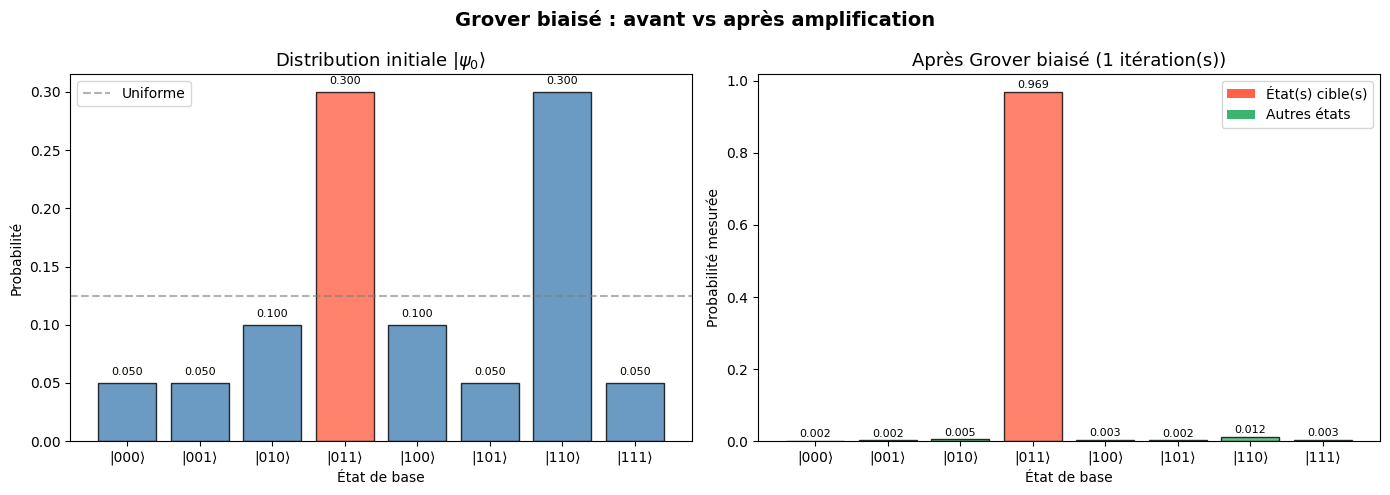

## Points clés

**Algorithme de Grover biaisé classique:**
- Reflète par rapport à l'état initial |ψ₀⟩ au lieu de la superposition uniforme
- Utile quand on dispose d'une information *a priori* sur la distribution des solutions
- Convergence plus rapide si les états cibles ont une haute probabilité initiale

**Algorithme DEGGA hybride:**
- Introduit un paramètre de phase φ pour améliorer les performances
- Permet une optimisation plus fine pour chaque distribution
- Peut surpasser le Grover biaisé standard selon les paramètres

**Recommandations:**
- Utiliser le DEGGA quand la distribution initiale est bien connue
- Balayer les paramètres (k, φ) pour trouver l'optimum pour votre cas spécifique
- Les gains du DEGGA dépendent fortement de la structure de la distribution initiale

## Comment utiliser ce notebook

### Pour tester une autre distribution:
Modifiez dans la section "Paramètres et distributions":
```python
selected_distribution = "defavorable"  # ou "uniforme", "tres_concentree"
```

### Pour ajouter votre propre distribution:
```python
DISTRIBUTIONS["ma_distribution"] = np.array([...])  # vos amplitudes
```

### Pour analyser une distribution en détail:
Modifiez dans la section "Analyse détaillée":
```python
analysis_dist = "ma_distribution"
```